In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numba import njit

@njit
def model_2_w_delays(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M,  selection_period, T_relax):
    y = y.reshape(2 + 2*M + 2*N*M) #for some reason without this y = [y0,y1,...,yn] becomes y = [[y0],[y1],...,[yn]]
    k_vec = CP * gamma_vec
    i_scalars = slice(0,2)
    i_B0 = slice(2, 2 + M)
    i_Bp = slice(2 + M, 2 + 2*M)
    i_Bpnp = slice(2 + 2*M, 2 + 2*M + N*M)
    i_Bi = slice(2 + 2*M + N*M, 2 + 2*M + 2*N*M)
    P = y[0]
    Bc = y[1]
    B0 = y[i_B0]
    Bp = y[i_Bp]
    #The pilus and lysis delay states are structured as B[N*i + j] is the jth state of strain i
    Bpnp = y[i_Bpnp]
    Bi = y[i_Bi]

   
    antibiotic_rate = 0
    if t-selection_period < 0: #sets the fitness cost/benefit of plasmid over time
        pass
    else: 
        if t - selection_period < 500: #sets the selection period to last 500 hours
            antibiotic_rate = 2.0
        else:
            antibiotic_rate = 0  

    C = 1 - (Bc + sum(B0) + sum(Bp) + sum(Bpnp) + sum(Bi))/K 
    dB0dt =  alpha*C*(B0 + pl*(1+cost)*Bp) - np.dot(gamma_vec, Bp)*B0 - delta*B0  - antibiotic_rate*B0 + (1/T_relax)*(np.sum(B0)/(M-1) - B0*M/(M-1)) 
    dBpdt = alpha*(1 + cost)*C*(1 - pl)*Bp + N/T_pili*Bpnp[N-1::N] - (k_vec*P)*Bp - delta*Bp + (1/T_relax)*(np.sum(Bp)/(M-1) - Bp*M/(M-1))  #[N-1::N] grabs every Nth element after element M to grab the last delay state for each strain
    dPdt = b*N/T_lysis*sum(Bi[N-1::N]) - delta_P * P
    dBcdt = alpha*C*Bc- delta*Bc - antibiotic_rate*Bc

    ##################################
    #delay states for conjugative pili
    ##################################
    dBpnpdt = np.zeros(len(Bpnp))
    #iterate through each strain i
    for i in range(M):
        Bpnp_i = Bpnp[i*N : (i+1)*N]
        dBpnp_idt = np.zeros(len(Bpnp_i))
        #iterate over each intermediate state j
        dBpnp_idt[0] = np.dot(gamma_vec, Bp)*B0[i] - (N/T_pili + delta)*Bpnp_i[0]
        for j in range(1, len(Bpnp_i)):
            dBpnp_idt[j] = N/T_pili*Bpnp_i[j-1] - (N/T_pili + delta)*Bpnp_i[j]
            
        dBpnpdt[i*N : (i+1)*N] = dBpnp_idt

    #################################
    #delay states for infection
    #################################
    dBidt = np.zeros(len(Bi))
    #iterate through each strain i
    for i in range(M):
        Bi_i = Bi[i*N : (i+1)*N]
        dBi_idt = np.zeros(len(Bi_i))
        #iterate over each intermediate state j
        dBi_idt[0] = k_vec[i]*Bp[i]*P - (N/T_lysis + delta)*Bi_i[0]
        for j in range(1, len(Bi_i)):
            dBi_idt[j] = N/T_lysis*Bi_i[j-1] - (N/T_lysis + delta)*Bi_i[j]
            
        dBidt[i*N : (i+1)*N] = dBi_idt

    #Assemble the output
    dydt = np.zeros(len(y))
    dydt[i_scalars] = [dPdt, dBcdt]
    dydt[i_B0] = dB0dt
    dydt[i_Bp] = dBpdt
    dydt[i_Bpnp] = dBpnpdt
    dydt[i_Bi] = dBidt

    return dydt

#Define parameters
alpha = 1.0        # Growth rate of the bacteria w/o the plasmid
gamma_hi = 1*10**(-8)     # Conjugation rate
gamma_lo = 10**(-12)
delta = 0.1     #Death rate of bacteria
b = 10**2     # Burst size of phage
delta_P = 0.1      # Rate of background death of phage
K = 10**8  #carrying capacity
cost = -0.5 #growth cost of plasmid
selection_period = 87600 #length of time before positive selection event (hours in 10 years)
pl = 0.001     # Probability of losing the plasmid

T_lysis = 0.5
T_pili = 0.5
T_relax = 100

N = 5 #number of intermediate states
M = 20 #number of different conjugation rates
gamma_vec = np.logspace(-12,-8, M)

#Simulation parameters
tf = 1*10**5 #Time to be simulated
dt_save = 1.0 #time span between saved data points
tEq = 2000


i_scalars = slice(0,2)
i_B0 = slice(2, 2 + M)
i_Bp = slice(2 + M, 2 + 2*M)
i_Bpnp = slice(2 + 2*M, 2 + 2*M + N*M)
i_Bi = slice(2 + 2*M + N*M, 2 + 2*M + 2*N*M)

#Define exctinction events (params are needed because solve_ivp always calls the event functions using them)
def B0_extinction_event(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M, selection_period, T_relax):
    return sum(y[i_B0]) - 1
B0_extinction_event.terminal = True
B0_extinction_event.direction = -1

def Bp_extinction_event(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M, selection_period, T_relax):
    return sum(y[i_Bp]) + sum(y[i_Bpnp]) - 1
Bp_extinction_event.terminal = True
Bp_extinction_event.direction = -1

def P_extinction_event(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M, selection_period, T_relax):
    return y[0] - 1
P_extinction_event.terminal = True
P_extinction_event.direction = -1

def Bc_extinction_event(t, y, alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M, selection_period, T_relax):
    return y[1] - 1
Bc_extinction_event.terminal = True
Bc_extinction_event.direction = -1

## Calculate panel A

In [2]:
CP = 10**(-1) #constant of proportionality between the congugation constant and the phage predation constant (due to pilus expression)

params = [alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M, selection_period, T_relax]

# Initial condition
B00 = np.ones(M)*K/(10*M)
Bp0 = np.ones(M)*K/M
Bpnp0 = np.zeros(N*M)
Bi0 = np.zeros(N*M)
P0 = 10
Bc0 = 0 #add competitor after equilibrium is reached

#Assemble initial condition
scalar_vars0 = [P0, Bc0]
y0 = np.empty(2 + 2*M + 2*N*M)
i_scalars = slice(0,2)

y0[i_scalars] = scalar_vars0
y0[i_B0] = B00
y0[i_Bp] = Bp0
y0[i_Bpnp] = Bpnp0
y0[i_Bi] = Bi0


t0 = 0

solEq = solve_ivp(
        model_2_w_delays,
        [t0, tEq],
        y0,
        args = params,
        dense_output=False,
        vectorized = True,
        method='LSODA', 
        max_step=10.0,
    )


yEq = solEq.y[:, -1].copy()
y0 = yEq
y0[1] = 10 #add competitor

extinction_events = [B0_extinction_event, Bp_extinction_event, P_extinction_event, Bc_extinction_event]

t_all = []
y_all = []
t0 = 0
while t0 < tf:
    sol = solve_ivp(
        model_2_w_delays,
        [t0, tf],
        y0,
        events=extinction_events,
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=10.0,
    )

    # Store results
    t_all.extend(sol.t)
    y_all.extend(sol.y.T)
    # Check which event triggered
    triggered = [len(ev) > 0 for ev in sol.t_events]
    y0 = sol.y[:, -1].copy()
    

    if triggered[0]:  #plasmid-free extinction
        y0[i_B0] = 0.0
    if triggered[1]:  #plasmid extinction
        y0[i_Bp] = 0.0
        y0[i_Bpnp] = 0.0
    if triggered[2]:  #phage extinction
        y0[0] = 0.0
    if triggered[3]:  #competitor extinction
        y0[1] = 0.0

    if not any(triggered):
        break  # no events, done
    else:
        t0 = sol.t[-1]

data1 = np.array(y_all)
t1 = t_all.copy()

B0_total = np.sum(data1[:, i_B0], axis=1)
Bp_total = np.sum(data1[:, i_Bp], axis=1)
P = data1[:, 0]
Bc = data1[:, 1]
plot_data1 = [B0_total, Bp_total, P, Bc]


## Calculate panel B

In [3]:
CP = 10**(0) #constant of proportionality between the congugation constant and the phage predation constant (due to pilus expression)

params = [alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M, selection_period, T_relax]

# Initial condition
B00 = np.ones(M)*K/(10*M)
Bp0 = np.ones(M)*K/M
Bpnp0 = np.zeros(N*M)
Bi0 = np.zeros(N*M)
P0 = 10#gamma_hi/k_hi*B0
Bc0 = 0 #add competitor after equilibrium is reached

#Assemble initial condition
scalar_vars0 = [P0, Bc0]
y0 = np.empty(2 + 2*M + 2*N*M)

y0[i_scalars] = scalar_vars0
y0[i_B0] = B00
y0[i_Bp] = Bp0
y0[i_Bpnp] = Bpnp0
y0[i_Bi] = Bi0


t0 = 0
solEq = solve_ivp(
        model_2_w_delays,
        [t0, tEq],
        y0,
        args = params,
        dense_output=False,
        vectorized = True,
        method='LSODA', 
        max_step=10.0,
    )

yEq = solEq.y[:, -1].copy()
y0 = yEq
y0[1] = 10 #add competitor

extinction_events = [B0_extinction_event, Bp_extinction_event, P_extinction_event, Bc_extinction_event]

t_all = []
y_all = []
t0 = 0
while t0 < tf:
    sol = solve_ivp(
        model_2_w_delays,
        [t0, tf],
        y0,
        events=extinction_events,
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=10.0
    )

    # Store results
    t_all.extend(sol.t)
    y_all.extend(sol.y.T)
    # Check which event triggered
    triggered = [len(ev) > 0 for ev in sol.t_events]
    y0 = sol.y[:, -1].copy()

    if triggered[0]:  #plasmid-free extinction
        y0[i_B0] = 0.0
    if triggered[1]:  #plasmid extinction
        y0[i_Bp] = 0.0
        y0[i_Bpnp] = 0.0
    if triggered[2]:  #phage extinction
        y0[0] = 0.0
    if triggered[3]:  #competitor extinction
        y0[1] = 0.0

    if not any(triggered):
        break  # no events, done
    else:
        t0 = sol.t[-1]

data2 = np.array(y_all)
t2 = t_all.copy()

B0_total = np.sum(data2[:, i_B0], axis=1)
Bp_total = np.sum(data2[:, i_Bp], axis=1)
P = data2[:, 0]
Bc = data2[:, 1]
plot_data2 = [B0_total, Bp_total, P, Bc]

## Calculate panel C

In [4]:
CP = 10**(1) #constant of proportionality between the congugation constant and the phage predation constant (due to pilus expression)
params = [alpha, delta, CP, b, delta_P, K, cost, pl, T_lysis, T_pili, N, gamma_vec, M, selection_period, T_relax]

# Initial condition
B00 = np.ones(M)*K/(10*M)
Bp0 = np.ones(M)*K/M
Bpnp0 = np.zeros(N*M)
Bi0 = np.zeros(N*M)
P0 = 10#gamma_hi/k_hi*B0
Bc0 = 0 #add competitor after equilibrium is reached

#Assemble initial condition
scalar_vars0 = [P0, Bc0]
y0 = np.empty(2 + 2*M + 2*N*M)
y0[i_scalars] = scalar_vars0
y0[i_B0] = B00
y0[i_Bp] = Bp0
y0[i_Bpnp] = Bpnp0
y0[i_Bi] = Bi0


t0 = 0
solEq = solve_ivp(
        model_2_w_delays,
        [t0, tEq],
        y0,
        args = params,
        dense_output=False,
        vectorized = True,
        method='LSODA', 
        max_step=10.0,
    )

yEq = solEq.y[:, -1].copy()
y0 = yEq
y0[1] = 10 #add competitor

extinction_events = [B0_extinction_event, Bp_extinction_event, P_extinction_event, Bc_extinction_event]

t_all = []
y_all = []
t0 = 0
while t0 < tf:
    sol = solve_ivp(
        model_2_w_delays,
        [t0, tf],
        y0,
        events=extinction_events,
        args = params,
        dense_output=False,
        method='LSODA', 
        max_step=10.0,
    )


    # Store results
    t_all.extend(sol.t)
    y_all.extend(sol.y.T)
    # Check which event triggered
    triggered = [len(ev) > 0 for ev in sol.t_events]
    y0 = sol.y[:, -1].copy()

    if triggered[0]:  #plasmid-free extinction
        y0[i_B0] = 0.0
    if triggered[1]:  #plasmid extinction
        y0[i_Bp] = 0.0
        y0[i_Bpnp] = 0.0
    if triggered[2]:  #phage extinction
        y0[0] = 0.0
    if triggered[3]:  #competitor extinction
        y0[1] = 0.0

    if not any(triggered):
        break  # no events, done
    else:
        t0 = sol.t[-1]





data3 = np.array(y_all)
t3 = t_all.copy()

B0_total = np.sum(data3[:, i_B0], axis=1)
Bp_total = np.sum(data3[:, i_Bp], axis=1)
P = data3[:, 0]
Bc = data3[:, 1]
plot_data3 = [B0_total, Bp_total, P, Bc]

## Create plots

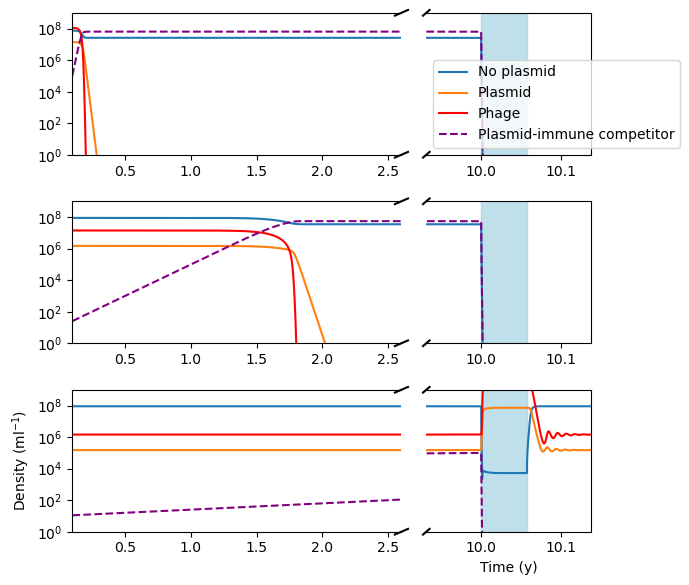

In [6]:
import matplotlib.pyplot as plt


datasets = [plot_data1, plot_data2, plot_data3]
times = [t1, t2, t3]
labels = ['No plasmid', 'Plasmid', 'Phage', 'Plasmid-immune competitor']
styles = ["-", "-", "-", "--"]
colors = ["tab:blue", "tab:orange", "Red", "Purple"]

#Define the x-lims for broken x-axis plot
xlim1 = (1, 7000)
xlim2 = (2400, t3[-1])

# Sample data
x1 = np.array(t1)/8760 #8760 hours in a year 
y1 = np.array(plot_data1)
x2 = np.array(t2)/8760
y2 = np.array(plot_data2)
x3 = np.array(t3)/8760
y3 = np.array(plot_data3)

# Group datasets
datasets = [(x1, y1), (x2, y2), (x3, y3)] 

# Broken x-axis segments
segments = [(0.1,2.6), ((selection_period-600)/8760, (selection_period +1200)/8760)]

# Create subplots: 3 stacked, 2 columns for the broken axis
fig, axes = plt.subplots(3, 2, sharey='row', figsize=(7, 6),  gridspec_kw={'width_ratios': [2, 1]})  # plots after break different size

for i, (x, y) in enumerate(datasets):
    for j, (xmin, xmax) in enumerate(segments):
        ax = axes[i, j]
        mask = (x >= xmin) & (x <= xmax)
        # Plot all components in this subplot
        #for component, style, label in zip(y,styles,labels):
        for y_component, style, label, color in zip(y, styles, labels, colors):
            ax.plot(x[mask], y_component[mask], linestyle=style, label=label, color = color)
            ax.axvspan(selection_period/8760, (selection_period + 500)/8760, color='lightblue', alpha=0.3, zorder=0) #color the background during positive selection
            ax.set_xlim(xmin, xmax)
            ax.set_yscale('log')
            ax.set_ylim(1, 10**9)
        
        # Hide internal spines and ticks
        if j == 0:
            ax.spines['right'].set_visible(False)
            ax.tick_params(right=False)
        else:
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)


        # Add diagonal break marks
        d = 0.02
        if j == 0:
            kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
            ax.plot((1-d, 1+d), (-d, +d), **kwargs)
            ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
        else:
            kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
            ax.plot((-d, +d), (-d, +d), **kwargs)
            ax.plot((-d, +d), (1-d, 1+d), **kwargs)

#removing the tick marks and labels on x axies except for bottom panel bottom
for ax in axes.flatten()[:-2]:  
    #ax.set_xticklabels([])           
    ax.tick_params(axis='x', bottom=True)  
    
# Set axis labels
axes[0][1].legend()
axes[-1, 0].set_ylabel('Density (ml$^{-1}$)' )
axes[-1, 1].set_xlabel('Time (y)')

plt.tight_layout()
plt.savefig('Figure_3_plots.svg', format = 'svg')